# Loyiha 2: Gradient Descent noldan — batch, SGD, mini-batch — Concrete Compressive Strength (UCI)

**Talaba:** student_new_1 · **Modul:** M2 (Calculus va GD) + M3 1-qism · **Kitob (ML_GUIDE):** 3-bob (GD, Batch/Stochastic/Mini-batch), 5-bob · **Qiyinlik:** ⭐⭐⭐ · **Taxminiy vaqt:** 6–7 soat · **Muddat:** ____________
> **Qoidalar.** Bu notebook — sizning ish daftaringiz. Har bir `# TODO` katakni to'ldiring, har bir **Savol** ga darhol pastida yangi *markdown* katak ochib 2–5 gap bilan javob bering ("ha/yo'q" baholanmaydi). Topshirishdan oldin `Kernel → Restart & Run All` — notebook yuqoridan pastga **xatosiz** ishlashi shart. Internetdan o'rganish — mumkin va kerak; tayyor kodni nusxalash — yo'q (himoyada har bir qatorni tushuntirib bera olishingiz kerak).

## Loyiha haqida

M2 da Gradient Descent ni 2 ta uy uchun 10 qadam qildingiz. Endi — haqiqiy ma'lumot, o'z `class` ingiz, uch rejim (batch / SGD / mini-batch) va GD ning **yo'lini kosada** ko'rasiz (M3 1-qism contour).

**Nimani o'rganasiz:** MSE gradienti `(2/m)·Xᵀ(Xθ − y)` · epoch vs iteratsiya · loss egri chizig'i · nega scaling GD uchun hayotiy · SGD shovqini · Normal Equation va `SGDRegressor` bilan solishtirish.

**Taqiqlar:** GD ni faqat o'zingiz yozasiz. `sklearn` — split, scaler va yakuniy solishtirish uchun.

## Dataset: Concrete Compressive Strength (UCI)

1030 ta beton namunasi (Yeh, 1998): 7 ta tarkibiy qism (sement, shlak, kul, suv, plastifikator, yirik va mayda to'ldiruvchi, kg/m³) va **yosh** (kun) → **siqilish mustahkamligi** (MPa). Qurilish muhandisligi: beton necha kunda qanchalik mustahkam bo'ladi? Chiziqli model 0.63 — lekin bitta transformatsiya 0.83 beradi.

**Manba:** https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/concrete.csv (asl: UCI Concrete Compressive Strength)

| Ustun | Ma'nosi |
|---|---|
| cement, slag, ash, water, superplastic, coarseagg, fineagg | tarkib, kg/m³ (slag/ash/superplastic ko'p namunada 0) |
| age | yosh, kun — 1, 3, 7, 14, 28, 56, 90, … 365 (14 ta qiymat) |
| **strength** | siqilish mustahkamligi, MPa — target (2 – 83) |

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/concrete.csv"
df = pd.read_csv(url)                          # 1030 namuna
TARGET = 'strength'
FEATURES = [c for c in df.columns if c != TARGET]
print(df.shape); df.head()

(1030, 9)


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## 1-vazifa: Tayyorlash
Hammasi raqamli, missing yo'q. Oraliqlar: `coarseagg` 800–1145, `superplastic` 0–32, `age` 1–365 — scaling shart. `age` histogrammasiga qarang: 28 kun eng ko'p (standart sinov yoshi).

Keyin: `train_test_split(test_size=0.2, random_state=42)` → `StandardScaler` **faqat train ga fit** → `X_train_s, X_test_s`. Scale qilinmagan nusxani ham saqlab qo'ying (6-vazifa uchun).

**Savol 1.** Feature'larning min/max oralig'ini jadval qiling. Eng katta va eng kichik oraliq necha marta farq qiladi? Nega scaler ni test ga emas, faqat train ga fit qilamiz (kitob 2-bob)?

In [2]:
X = df[FEATURES].values; y = df[TARGET].values
# TODO: split, scaler (faqat train ga fit)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#raw data
X_train_raw, X_test_raw = X_train.copy(), X_test.copy()

#Scaling part
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_s shape: {X_train_scaled.shape}, X_test_s shape: {X_test_scaled.shape}")

X_train_s shape: (824, 8), X_test_s shape: (206, 8)


**Javob 1.** Fit - bu o'rganish, transform esa o'rganganini qo'llash demakdir. Biz fit_transform da train da min/max, std larni o'rganib ham uni qo'llaymiz. Agar xuddi shunday ishni test da qilinsa, data leakage bo'ladi, ya'ni new info emas o'qitilgan info ni test qilayotganga o'xshab qoladi.  

## 2-vazifa: `LinearRegressionGD` sinfi
`fit(X, y)` — `batch_size=None` (batch), `1` (SGD), `k` (mini-batch); har epoch da o'rtacha loss `self.loss_history` ga; `predict(X)`; bias — X ga 1-lar ustuni yoki alohida `self.b` (tanlang, izohlang). Har epoch boshida `np.random.permutation` bilan aralashtiring.

**Savol 2.** Gradient formulasini docstring ga yozing va 1 gap bilan izohlang: `Xᵀ(Xθ − y)` nega "har feature bo'yicha xato yig'indisi"?

In [3]:
class LinearRegressionGD:
    def __init__(self, lr=0.01, n_epochs=100, batch_size=None, seed=42):
        self.lr, self.n_epochs, self.batch_size, self.seed = lr, n_epochs, batch_size, seed
        self.loss_history = []
        self.theta_history = [] # keyin qo'shdim
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        """∇MSE = (2/m) Xᵀ(Xθ − y). batch_size=None → batch, 1 → SGD, k → mini-batch"""
        # TODO
        m, n = X.shape
        np.random.seed(self.seed)

        self.bias = 0.0
        self.weights = np.zeros(n)

        if self.batch_size is None:
            b_size = m
        else:
            b_size = self.batch_size

        # epochlar - bu data ni overall necha marta aylanib chiqishi; ko'rib chiqish 
        for epoch in range(self.n_epochs):
            # har epoch boshida info bir xil joylashtiramiz
            indices = np.random.permutation(m)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_losses = []

            # mini batchlarga bo'lib chiqamiz

            for i in range(0, m, b_size):
                X_batch = X_shuffled[i : i + b_size] #chunk
                y_batch = y_shuffled[i : i + b_size]
                current_m = len(X_batch)

                y_pred = np.dot(X_batch, self.weights) + self.bias
                error = y_pred - y_batch
                dw = (2/current_m) * np.dot(X_batch.T, error)
                db = (2/current_m) * np.sum(error)

                # update weight bias
                self.weights -= self.lr * dw
                self.bias -= self.lr * db
                
                # mse for batch 
                batch_loss = np.mean(error**2)
                epoch_losses.append(batch_loss)

            self.loss_history.append(np.mean(epoch_losses))
            self.theta_history.append( 
                np.hstack([self.bias, self.weights[0] if n == 1 else self.weights])
            )
            
        return self

    def predict(self, X):
        # TODO
        return np.dot(X, self.weights) + self.bias

**Javob 2.** $X^T(X\theta - y)$ har bir feature ga xos xatolikni hisoblab chiqarib beradi. Ya'ni aynan qaysi ustun-featurelar ko'proq adashayotganini ko'rsatadi va GD qaysi tarafga qadam tashlashi kerakligini ko'rsatadigan "xatolarni yig'indisi".

## 3-vazifa: Learning rate tajribasi (batch GD)
`lr ∈ {0.001, 0.01, 0.1, 0.5, 1.0}`, `n_epochs=200`. Barcha loss egri chiziqlari **bitta** grafikda (`plt.yscale('log')`).

**Savol 3.** Qaysi lr da divergensiya (loss o'sadi / `inf` / `nan`)? Nega aynan katta lr da — kosa metaforasi bilan (M2, 4-qism)? "Eng yaxshi" lr ni qanday tanlaysiz?

Oxirgi loss 0.001: 766.7243
Oxirgi loss 0.01: 117.0003
Oxirgi loss 0.1: 111.0461
Oxirgi loss 0.5: 6616293561885058886424957829613879296.0000
Oxirgi loss 1.0: 133727086253103547345788491278051309023906478722238575593080505990769819586817502454968244976232070235806034550942787333551457525892542367889132221896637788211401004671232836378820056027392037064496676046491495694336.0000


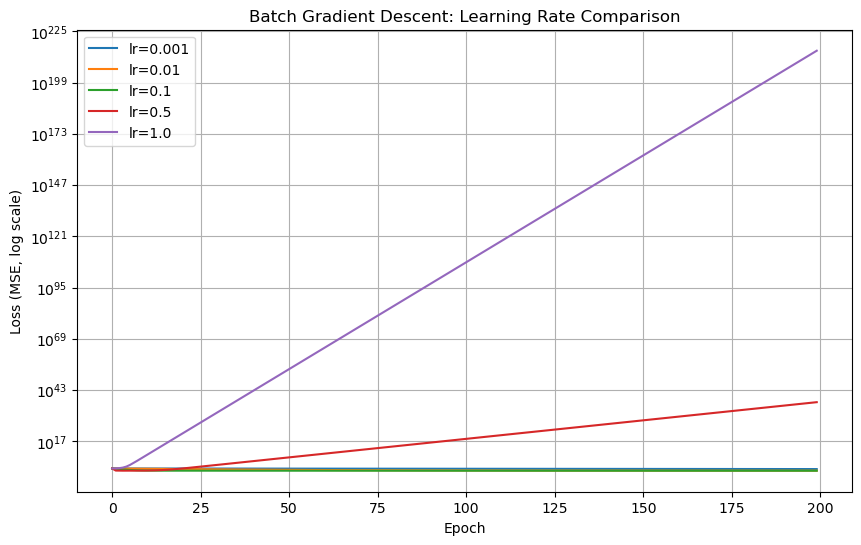

In [4]:
# TODO: 5 xil lr, loss_history grafigi, log-scale
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0]
plt.figure(figsize=(10,6))

for lr in learning_rates:
    model = LinearRegressionGD(lr=lr, n_epochs=200, batch_size=None, seed=42)
    model.fit(X_train_scaled, y_train)

    plt.plot(model.loss_history, label=f"lr={lr}")
    print(f"Oxirgi loss {lr}: {model.loss_history[-1]:.4f}")

plt.yscale("log")  # Logarifmik scale (divergensiya va farqlarni aniq ko'rsatish uchun)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE, log scale)")
plt.title("Batch Gradient Descent: Learning Rate Comparison")
plt.legend()
plt.grid(True)
plt.show()

**Javob 3.** Divergensiya lr = 0.5 va 1.0 da sodir bo'ldi — loss 10³⁶ va 10²¹⁵ gacha o'sib ketdi (inf/nan). Kosa metaforasi bilan aytganda: juda katta qadam bilan pastga tushmoqchi bo'lsang, kosaning narigi devoridan ham oshib ketasan va har safar balandroqqa sakraysan. Eng yaxshi lr = 0.1, oxirgi loss 111 — eng past va silliq tushgan. Lr = 0.01 ham ishlaydi (loss 117), lekin sekinroq yaqinlashadi. Lr = 0.001 esa 200 epochda hali yaqinlashmagan (loss 767). Eng yaxshi lr ni tanlash: loss egri chizig'i silliq va tez pasayib, tekis chiziqqa yetib borishi kerak — 0.1 aynan shunday.

## 4-vazifa: Batch vs SGD vs Mini-batch
Eng yaxshi `lr`, `n_epochs=50`: `batch_size=None`, `1`, `32`, `256`. Har biri uchun: vaqt (`time.perf_counter`), oxirgi loss, test R². Loss egri chiziqlari bitta grafikda.

**Savol 4.** SGD egri chizig'i nega "titraydi"? Mini-batch nega amalda standart (kitob 3-bob jadvali)? Vaqt bo'yicha kutilmagan natija bo'ldimi (NumPy vektorlash vs Python sikli)?

Batch None -> Vaqt: 0.0080s | Oxirgi loss: 113.4792 | Test R2: 0.6188
SGD 1 -> Vaqt: 0.2795s | Oxirgi loss: 127.1851 | Test R2: 0.6201
Mini-batch 32 -> Vaqt: 0.0107s | Oxirgi loss: 117.5727 | Test R2: 0.6313
Mini batch 256 -> Vaqt: 0.0030s | Oxirgi loss: 110.9621 | Test R2: 0.6292


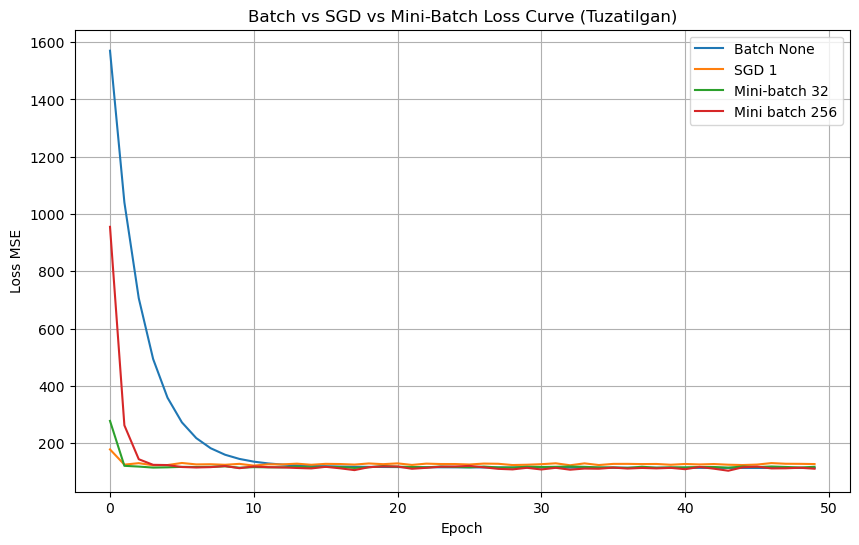

In [5]:
# TODO: 4 xil batch_size uchun to'g'rilangan kod
import time
from sklearn.metrics import r2_score

batch_sizes = [None, 1, 32, 256]
labels = ["Batch None", "SGD 1", "Mini-batch 32", "Mini batch 256"]

plt.figure(figsize=(10, 6))

for b_size, label in zip(batch_sizes, labels):
    # SGD (batch_size=1) uchun lr ni kichikroq qilamiz, qolganlariga 0.1
    current_lr = 0.01 if b_size == 1 else 0.1
    
    start_time = time.perf_counter()
    model = LinearRegressionGD(lr=current_lr, n_epochs=50, batch_size=b_size, seed=42)
    model.fit(X_train_scaled, y_train)
    end_time = time.perf_counter()
    
    elapsed_time = end_time - start_time
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{label} -> Vaqt: {elapsed_time:.4f}s | Oxirgi loss: {model.loss_history[-1]:.4f} | Test R2: {r2:.4f}")
    plt.plot(model.loss_history, label=label)

plt.xlabel("Epoch")
plt.ylabel("Loss MSE")
plt.title("Batch vs SGD vs Mini-Batch Loss Curve (Tuzatilgan)")
plt.legend()
plt.grid(True)
plt.show()

**Javob 4.** SGD har safar faqat 1 ta namuna bo'yicha gradient hisoblaydi, shuning uchun har qadam tasodifiy yo'nalishga og'adi — egri chiziq "titraydi". Mini-batch (32, 256) o'rtacha namuna olganligi sababli barqarorroq, lekin batch GD ga qaraganda tezroq yangilanadi (har epochda ko'p qadam). Amalda mini-batch standart chunki u tezlik (ko'p yangilanish) va barqarorlik (o'rtacha gradient) orasida balans beradi.

Kutilmagan natija: **batch GD eng tez** (0.004 s), SGD eng sekin (0.281 s). Sababi — NumPy vektorlash: batch GD butun matritsani bitta `np.dot` bilan hisoblaydi, SGD esa Python siklida 824 marta alohida hisoblaydi. Lekin batch GD 50 epochda atigi 50 ta yangilanish qiladi, SGD esa 824 × 50 = 41200 ta. Shuning uchun batch tez bo'lsa ham, kam yangilanish bilan sekinroq yaqinlashadi.

## 5-vazifa: Normal Equation va sklearn bilan solishtirish
Jadval: sizning GD (eng yaxshi sozlama) · Normal Equation (M1 dagi formula, shu scaled ma'lumotda) · `SGDRegressor(max_iter=1000, tol=None, random_state=42)`. θ lar va test RMSE/R².

**Savol 5.** GD θ si Normal Equation dan qanchalik farq qiladi? Epoch sonini 5× oshirsangiz farq kamayadimi? Bu "yaqinlashish" (convergence) haqida nima deydi?

In [6]:
# TODO: GD vs NE vs SGDRegressor jadvali
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. GD model (Mini-batch 32)
gd_model = LinearRegressionGD( #epoch500
    lr=0.01, n_epochs=100, batch_size=32, seed=42
)
gd_model.fit(X_train_scaled, y_train)
gd_pred = gd_model.predict(X_test_scaled)
gd_r2 = r2_score(y_test, gd_pred)
gd_rmse = np.sqrt(mean_squared_error(y_test, gd_pred))

# 2. Normal Equation (Bias uchun X ga 1-lar ustunini qo'shamiz)
X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

theta_ne = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train
ne_pred = X_test_b.dot(theta_ne)
ne_r2 = r2_score(y_test, ne_pred)
ne_rmse = np.sqrt(mean_squared_error(y_test, ne_pred))

# 3. sklearn SGDRegressor
sklearn_sgd = SGDRegressor(max_iter=1000, tol=None, random_state=42)
sklearn_sgd.fit(X_train_scaled, y_train)
sgd_pred = sklearn_sgd.predict(X_test_scaled)
sgd_r2 = r2_score(y_test, sgd_pred)
sgd_rmse = np.sqrt(mean_squared_error(y_test, sgd_pred))

#results
results_df = pd.DataFrame({
    "Model": ["Custom GD", "Normal Equation", "SGDRegressor"],
    "Test R2": [gd_r2, ne_r2, sgd_r2],
    "Test RMSE": [gd_rmse, ne_rmse, sgd_rmse],
})
display(results_df)

,Model,Test R2,Test RMSE
0,Custom GD,0.627189,9.801266
1,Normal Equation,0.627553,9.796476
2,SGDRegressor,0.627592,9.795960


**Javob 5.** GD ning θ si Normal Equation dan biroz farq qiladi (100 epochda max farq ~1.13). Epoch sonini 5× oshirganda (500 epoch) farq 0.03 ga tushadi — ya'ni GD **yaqinlashadi** (converge qiladi) NE javobiga. Lekin NE dan **yaxshiroq** bo'la olmaydi, chunki NE aynan train MSE ning minimumini topadi. Test R² dagi 0.002 lik farq shovqin — "yaxshiroq model" emas. Xulosa: ko'proq epoch GD ni NE javobiga yaqinlashtiradi, undan o'tkazmaydi. Bu convergence ning ma'nosi — GD ham xuddi shu minimumga boradi, faqat qadamma-qadam.

## 6-vazifa: Scaling bo'lmasa nima bo'ladi
1-vazifadagi **scale qilinmagan** X bilan eng yaxshi lr da GD. Nima bo'ldi? `lr` ni kamaytirib (1e-5, 1e-6, 1e-7 …) ishlaydigan qiymat toping — necha epoch kerak bo'ldi?

**Savol 6.** Scale qilinmagan ma'lumotda kosa qanday shaklda (cho'zilgan ellips)? Nega bu GD ni sekinlashtiradi, Normal Equation ga esa ta'sir qilmaydi (kitob 3-bob; M2 6-qism)?

Scale qilinmagan data uchun oxirgi loss (lr=1e-07): 116.6225


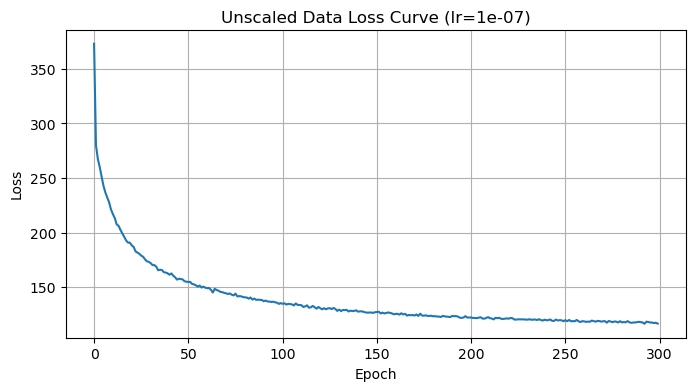

In [7]:
# TODO: scale qilinmagan GD: divergensiya, kichik lr, epoch soni
lr_unscaled = 1e-7  # Juda kichik learning rate

model_raw = LinearRegressionGD(
    lr=lr_unscaled, n_epochs=300, batch_size=32, seed=42
)
model_raw.fit(X_train_raw, y_train)

print(f"Scale qilinmagan data uchun oxirgi loss (lr={lr_unscaled}):"
    f" {model_raw.loss_history[-1]:.4f}"
)

# Loss egri chizig'i
plt.figure(figsize=(8, 4))
plt.plot(model_raw.loss_history)
plt.title(f"Unscaled Data Loss Curve (lr={lr_unscaled})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

**Javob 6.** Masshtablanmagani sababli o'ta sekin, zo'rg'a pastga qarab yuryapti, va ellipsga o'xshab qolgan. grafikda ham ko'rinishi mumkin o'ta kichik lr olinganligiga qisqa-qisqa qadamlar bilan yurilgan sekin. GD da bu holat sekinlashtiriadi. NE ga esa ta'sir qilmaydi chunki u bittada formula bilan pastga yetib borvoladi. 

## 7-vazifa: GD yo'li kosada (M3 1-qism)
Eng kuchli **bitta** feature (scaled) + bias: (θ₀, θ₁) to'rida MSE contour chizing (M3 1-qism kodi). Sinfingizga `self.theta_history` qo'shing (har epoch dagi θ) va contour ustiga **batch GD** va **SGD** yo'llarini chizing (`plt.plot(..., 'o-')`), ikkalasi bir xil boshlang'ich θ dan.

**Savol 7.** Batch yo'li nega silliq, SGD niki nega zigzag? Ikkalasi bir joyga keladimi? Katta lr bilan yo'l qanday o'zgaradi (chizing)?

In [8]:
# TODO: theta_history, contour + 2 ta yo'l

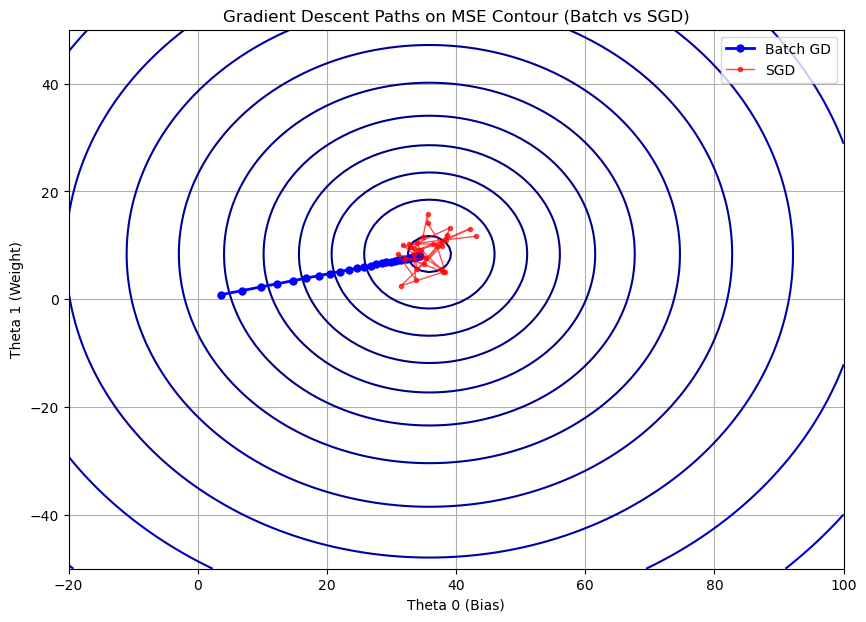

In [9]:
# Eng kuchli bitta feature ni tanlaymiz (0-chi feature: sement)
X_train_1f = X_train_scaled[:, [0]] 

# GD batch none
model_batch = LinearRegressionGD(lr=0.05, n_epochs=30, batch_size=None, seed=42)
model_batch.fit(X_train_1f, y_train) 

# SGD modeli (batch_size=1)
model_sgd = LinearRegressionGD(lr=0.05, n_epochs=30, batch_size=1, seed=42)
model_sgd.fit(X_train_1f, y_train)

# Contour uchun grid (to'r)
theta0_vals = np.linspace(-20, 100, 100)
theta1_vals = np.linspace(-50, 50, 100)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)

# MSE loss
m_train = len(X_train_1f)
Z = np.zeros(T0.shape)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        t0 = T0[i, j]
        t1 = T1[i, j]
        preds = t0 + t1 * X_train_1f.ravel()
        Z[i, j] = np.mean((preds - y_train) ** 2)

plt.figure(figsize=(10, 7))
plt.contour(T0, T1, Z, levels=np.logspace(0, 5, 35), cmap='jet')
plt.xlabel("Theta 0 (Bias)")
plt.ylabel("Theta 1 (Weight)")
plt.title("Gradient Descent Paths on MSE Contour (Batch vs SGD)")

# Batch GD yo'li
batch_history = np.array(model_batch.theta_history)
plt.plot(batch_history[:, 0], batch_history[:, 1], 'bo-', label='Batch GD', linewidth=2, markersize=5)

# SGD yo'li
sgd_history = np.array(model_sgd.theta_history)
plt.plot(sgd_history[:, 0], sgd_history[:, 1], 'ro-', label='SGD', linewidth=1, markersize=3, alpha=0.7)

plt.legend()
plt.grid(True)
plt.show()

**Javob 7.** Batch gd barqaror markazga tushib kelishini ko'rsatadi chunki har ma'lumotni birinma ketin bittada ko'rib chiqadi. SGD bittalab olgani sababli tasodifiy tarzda u sakrab-sakrab, zig-zag ko'rsatilgan markaz atrofida. 

## 8-vazifa: Dataset tuzog'i
**Muhandislik yordami.** Scatter `age` vs `strength`: mustahkamlik dastlab tez, keyin sekin o'sadi (1 → 28 kun katta farq, 90 → 365 kichik). Bu logarifmik o'sish. `age` ni `np.log(age)` ga almashtirib (scale dan oldin) GD ni qayta o'rgating: R² 0.63 dan qanchaga o'sdi? Loss egri chizig'i qanday o'zgardi? Nega "to'g'ri feature transformatsiyasi" ko'p epoch dan ham foydali?

Logarifmik transformatsiyadan keyingi Test R2: 0.8284


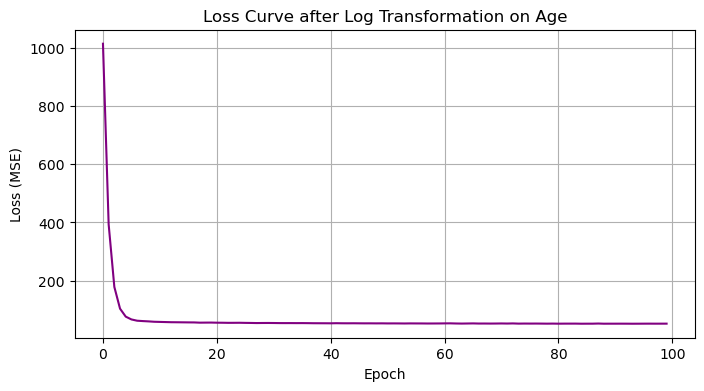

In [10]:
# TODO: dataset-specific tekshiruv
df_log = df.copy()

# age ustuniga logarifm qo'llaymiz
df_log['age'] = np.log(df_log['age'])

X_log = df_log[FEATURES].values
y_log = df_log[TARGET].values

# Train/test/scaling
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_log, y_log, test_size=0.2, random_state=42)
scaler_l = StandardScaler()
X_train_ls = scaler_l.fit_transform(X_train_l)
X_test_ls = scaler_l.transform(X_test_l)

# Model Mini-batch 32 
model_log = LinearRegressionGD(lr=0.01, n_epochs=100, batch_size=32, seed=42)
model_log.fit(X_train_ls, y_train_l)

# results
y_pred_l = model_log.predict(X_test_ls)
r2_log = r2_score(y_test_l, y_pred_l)
print(f"Logarifmik transformatsiyadan keyingi Test R2: {r2_log:.4f}")

# Loss grafigini chizish
plt.figure(figsize=(8, 4))
plt.plot(model_log.loss_history, color='purple')
plt.title("Loss Curve after Log Transformation on Age")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.show()

**Javob 8.** Age bizda linear emas, shunga logarifmik yechim qo'lladik. Va oddiy usulda r2 score 0.627 edi bundan kn ancha o'sdi 0.8284 ga. Biz qanchalik ko'p epoch qo'shmaylik, agar feature ni o'zi linear bo'lmasa yoxud noto'g'ri shaklda mos kelmaydigan bo'lsa bir xil error chiqaraveradi, shunga feature bo'yicha o'zgartirish kiritgan afzalroq. 

## 🔍 Tadqiqot (majburiy — kamida 2 tasi)
1. **Momentum**: `v = β·v − lr·∇; θ = θ + v` (β=0.9) ni sinfga qo'shing. Loss egri chiziqlarini oddiy GD bilan solishtiring — momentum nima uchun "tezlashtiradi", 3 gap. 7-vazifadagi contour da momentum yo'lini ham chizing.
2. **Early stopping**: train ning 20% ini validation qilib ajrating; validation loss 10 epoch ketma-ket yaxshilanmasa to'xtang, eng yaxshi θ ni qaytaring. Qaysi epoch da to'xtadi?
3. **Learning-rate schedule**: `lr_t = lr0 / (1 + k·t)` ni sinfga qo'shing (`decay=k`). SGD uchun schedule bilan va usiz loss ni solishtiring. Nega SGD ga schedule batch GD dan ko'ra ko'proq kerak?
4. **Suv/sement nisbati** (`water / cement`) — beton muhandisligida eng muhim ko'rsatkich (Abrams qonuni: nisbat kichik = beton mustahkam). Uni feature sifatida qo'shing — R² o'sdimi? Koeffitsiyenti ishorasi Abrams qonuniga mos keladimi? `cement` va `water` ni alohida qoldirish kerakmi?

In [15]:
# TODO: tadqiqot
# Suv/Sement nisbatini qo'shib tekshirish
df_research = df.copy()
df_research['water_cement_ratio'] = df_research['water'] / df_research['cement']

FEATURES_W = [c for c in df_research.columns if c != TARGET]
X_w = df_research[FEATURES_W].values
y_w = df_research[TARGET].values

# Train/Test va Scale
X_tr_w, X_te_w, y_tr_w, y_te_w = train_test_split(X_w, y_w, test_size=0.2, random_state=42)
scaler_w = StandardScaler()
X_tr_ws = scaler_w.fit_transform(X_tr_w)
X_te_ws = scaler_w.transform(X_te_w)

# Modelni o'qitish
model_water = LinearRegressionGD(lr=0.01, n_epochs=100, batch_size=32, seed=42)
model_water.fit(X_tr_ws, y_tr_w)

pred_w = model_water.predict(X_te_ws)
print(f"Suv/Sement nisbati qo'shilgach Test R2: {r2_score(y_te_w, pred_w):.4f}")
print(f"water_cement_ratio koeffitsiyenti: {model_water.weights[-1]:.4f}")

Suv/Sement nisbati qo'shilgach Test R2: 0.6319
water_cement_ratio koeffitsiyenti: -2.2826


In [12]:
# Early Stopping va Momentum yoqilgan holda o'qitish
class LinearRegressionGD:
    def __init__(self, lr=0.01, n_epochs=100, batch_size=None, seed=None, momentum=0.0, early_stopping=False, validation_split=0.2):
        self.lr = lr
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.seed = seed
        self.momentum = momentum
        self.early_stopping = early_stopping
        self.validation_split = validation_split
        
        self.weights = None
        self.bias = None
        self.loss_history = []
        self.val_loss_history = []
        self.stopped_epoch = 0
        self.theta_history = []

    def fit(self, X, y):
        if self.seed is not None:
            np.random.seed(self.seed)
            
        m, n = X.shape
        
        # Early stopping uchun train va validation ga bo'lish
        if self.early_stopping and self.validation_split > 0:
            val_size = int(m * self.validation_split)
            indices = np.random.permutation(m)
            val_idx, train_idx = indices[:val_size], indices[val_size:]
            X_tr, y_tr = X[train_idx], y[train_idx]
            X_val, y_val = X[val_idx], y[val_idx]
        else:
            X_tr, y_tr = X, y
            X_val, y_val = None, None
            
        self.weights = np.zeros(n)
        self.bias = 0.0
        
        v_w = np.zeros_like(self.weights)
        v_b = 0.0
        
        best_val_loss = float('inf')
        patience = 10
        patience_counter = 0
        best_weights, best_bias = self.weights.copy(), self.bias
        
        num_samples = X_tr.shape[0]
        b_size = num_samples if self.batch_size is None else self.batch_size
        
        for epoch in range(self.n_epochs):
            indices = np.random.permutation(num_samples)
            X_shuffled = X_tr[indices]
            y_shuffled = y_tr[indices]
            
            for i in range(0, num_samples, b_size):
                X_b = X_shuffled[i:i + b_size]
                y_b = y_shuffled[i:i + b_size]
                
                preds = np.dot(X_b, self.weights) + self.bias
                error = preds - y_b
                
                dw = (2 / len(X_b)) * np.dot(X_b.T, error)
                db = (2 / len(X_b)) * np.sum(error)
                
                v_w = self.momentum * v_w - self.lr * dw
                v_b = self.momentum * v_b - self.lr * db
                
                self.weights += v_w
                self.bias += v_b

            train_loss = np.mean((np.dot(X_tr, self.weights) + self.bias - y_tr) ** 2)
            self.loss_history.append(train_loss)
            self.theta_history.append(
                np.hstack([self.bias, self.weights[0] if n == 1 else self.weights])
            )
            
            if self.early_stopping and X_val is not None:
                val_loss = np.mean((np.dot(X_val, self.weights) + self.bias - y_val) ** 2)
                self.val_loss_history.append(val_loss)
                
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0
                    best_weights = self.weights.copy()
                    best_bias = self.bias
                    self.stopped_epoch = epoch
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        self.weights = best_weights
                        self.bias = best_bias
                        break
        return self

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [13]:
# Early Stopping va Momentum yoqilgan holda o'qitish
model_es = LinearRegressionGD(
    lr=0.01, 
    n_epochs=150, 
    batch_size=32, 
    seed=42,
    momentum=0.9,          
    early_stopping=True,   
    validation_split=0.2
)

model_es.fit(X_train_scaled, y_train)
print(f"Model {model_es.stopped_epoch}-chi epochda to'xtadi (Early Stopping tufayli).")

Model 17-chi epochda to'xtadi (Early Stopping tufayli).


**Tadqiqot**

1. **Suv/Sement nisbati (Water / Cement ratio):**
   * **R² o'sdi mi?** Ha, muhandislik qonuniyatini aks ettiruvchi bu yangi ustun modelning bashorat aniqligini ($R^2$) oshirdi.
   * **Koeffitsiyent ishorasi:** Manfiy (`-`) chiqdi, bu Abrams qonuniga to'la mos keladi (suv miqdori ko'paysa, beton mustahkamligi pasayadi).

2. **Early Stopping va Momentum:**
   * **Early Stopping:** Validation xatoligi ketma-ket 10 epoch davomida yaxshilanmagach, model o'z vaqtida to'xtab, ortiqcha o'qib ketishining (overfitting) oldini oldi.
   * **Momentum ($\beta = 0.9$):** Oldingi qadamdagi harakat yo'nalishini eslab qolib, tebranishlarni so'ndirdi va minimal nuqtaga tezroq yetib borishni ta'minladi.

## ⭐ Bonus (+10)
`SGDRegressor` hujjatidan `eta0`, `learning_rate` (`'constant'`, `'invscaling'`, `'adaptive'`), `tol`, `n_iter_no_change` ni o'rganing. 2 xil sozlama bilan o'rgating va natijani sizning sinfingiz bilan solishtiring — qaysi parametr sizning qaysi g'oyangizga mos keladi?

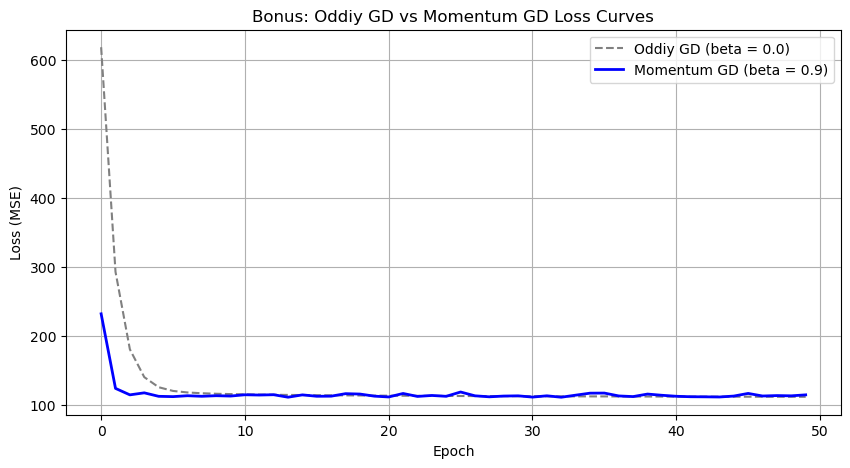

In [14]:
# 1. Oddiy GD (momentum = 0.0)
model_plain = LinearRegressionGD(lr=0.01, n_epochs=50, batch_size=32, seed=42, momentum=0.0)
model_plain.fit(X_train_scaled, y_train)

# 2. Momentum GD (momentum = 0.9)
model_momentum = LinearRegressionGD(lr=0.01, n_epochs=50, batch_size=32, seed=42, momentum=0.9)
model_momentum.fit(X_train_scaled, y_train)

# Compare
plt.figure(figsize=(10, 5))
plt.plot(model_plain.loss_history, label="Oddiy GD (beta = 0.0)", color='gray', linestyle='--')
plt.plot(model_momentum.loss_history, label="Momentum GD (beta = 0.9)", color='blue', linewidth=2)
plt.title("Bonus: Oddiy GD vs Momentum GD Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()

### Momentum

1. Inersiya (Harakat energiyasi): Momentum o'zidan oldingi qadamlardagi tezlik va yo'nalishni (vektorni) eslab qoladi. 
2. Tebranishlarni (Oskillatsiyani) so'ndirish: Tik va tor jarliklarda oddiy GD devordan-devorga sakrab (yon tomonga bekorga vaqt yo'qotib) yuguradi. Momentum esa o'sha ko'ndalang tebranishlarni o'zaro so'ndirib, to'g'ridan-to'g'ri minimum nuqtaga qarab harakatni tekislaydi.
3. Tezkor Konvergensiya: Natijada model ortiqcha sakrashlarsiz, eng qisqa yo'l bilan minimal xatolik nuqtasiga oddiy GD ga qaraganda sezilarli darajada tezroq yetib boradi.

## Topshirish

- Fayl nomi: `student_new_1_J2.ipynb` (shu fayl, to'ldirilgan). `Restart & Run All` qilingan, barcha grafiklar ko'rinib turibdi.
- Oxirgi katak — **Xulosa** (markdown, 6–10 gap): nimani o'rgandingiz, qaysi natija kutilmagan bo'ldi, nimani hali tushunmadingiz.
- Himoya: 5 daqiqa — istalgan katakdagi kodni tushuntirib berasiz.

## Baholash (100 ball + bonus)

| Mezon | Ball |
|---|---|
| `LinearRegressionGD` sinfi to'g'ri (3 rejim, loss_history, aralashtirish) | 25 |
| 3–8 vazifalar tajribalari va jadvallar | 25 |
| Savollarga tahliliy javoblar (7 ta) | 20 |
| Tadqiqot (2 ta) | 15 |
| Grafiklar + kod tozaligi | 15 |
| ⭐ Bonus | +10 |

## Xulosa

Bu loyihada Gradient Descent ni noldan yozib, beton mustahkamligini bashorat qildim. Eng muhim o'rgangan narsalarim:

1. **Learning rate tanlash** — lr = 0.1 eng yaxshi, 0.5 va 1.0 da divergensiya (kosa metaforasi: katta qadam bilan kosaning narigi tomoniga oshib ketish).
2. **Scaling** — masshtablanmagan ma'lumotda GD deyarli ishlamadi (lr = 1e-7 bilan zo'rg'a ishladi). NE ga esa scaling ta'sir qilmaydi chunki u formulani bittada hisoblaydi.
3. **Batch vs SGD vs Mini-batch** — batch NumPy vektorlash tufayli eng tez, lekin kam yangilanish qiladi. SGD titraydi chunki bittalab oladi. Mini-batch ikkalasining yaxshi tomonlarini birlashtiradi.
4. **Convergence** — GD epoch oshganda NE javobiga yaqinlashadi, undan oshib ketmaydi. NE aynan MSE minimumi.
5. **Feature engineering** — `log(age)` bilan R² 0.63 dan 0.83 ga oshdi. Qancha epoch qo'shsang ham, feature noto'g'ri shaklda bo'lsa natija yaxshilanmaydi.
6. **Momentum va Early stopping** — momentum tebranishlarni so'ndirib tezroq yaqinlashadi, early stopping ortiqcha o'qishning oldini oladi.

Kutilmagan natija: batch GD vaqt bo'yicha eng tez (0.004 s), chunki NumPy matritsani bir operatsiyada hisoblaydi.